In [56]:
import numpy as np
import pytreenet as ptn
from copy import deepcopy

In [57]:
def product_state(ttn, bond_dim=2 , physical_dim= 2):
    product_state = deepcopy(ttn)
    A = np.array([0, 1]) 
    #A = np.random.rand(2) + 1j * np.random.rand(2)
    for node_id in product_state.nodes.keys():
        n = product_state.tensors[node_id].ndim - 1
        tensor = A.reshape((1,) * n + (physical_dim,))
        T = np.pad(tensor, n*(( bond_dim-1, bond_dim-1),) + ((0, 0),))
        product_state.tensors[node_id] = T
        product_state.nodes[node_id].link_tensor(T)  
    return product_state

In [58]:
d = 2
shapes = {
    (0, 0): (2, 2, d),
    (0, 1): (2, 2, d),
    (0, 2): (2, 2, d),
    (0, 3): (2, 2, d),
    (0, 4): (2, 2)}

sites = {
    (0, j): ptn.random_tensor_node(shapes[(0, j)], identifier=f"Site({0},{j})") for j in range(5)
}

ttn = ptn.TreeTensorNetworkState()

ttn.add_root(sites[(0, 0)][0], sites[(0, 0)][1])

connections = [
    ((0, 0), (0, 1), 0, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (0, 3), 1, 0),
    ((0, 3), (0, 4), 1, 0)]


for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Site({parent[0]},{parent[1]})"
    child_id = f"Site({child[0]},{child[1]})"
    ttn.add_child_to_parent(sites[child][0], sites[child][1], child_leg, parent_id, parent_leg)

ttn = product_state(ttn , bond_dim= 10, physical_dim = d)

nodes = {
    (0, j): (ptn.Node(tensor=ttn.tensors[f"Site({0},{j})"].conj() , identifier=f"Node({0},{j})"), ttn.tensors[f"Site({0},{j})"].conj()) for j in range(5)
}

ttn.add_child_to_parent(nodes[(0,0)][0], nodes[(0,0)][1], 1, "Site(0,0)", 1)

connections = [
    ((0, 0), (0, 1), 1, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (0, 3), 1, 0),
    ((0, 3), (0, 4), 1, 0)]

for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Node({parent[0]},{parent[1]})"
    child_id = f"Node({child[0]},{child[1]})"
    ttn.add_child_to_parent(nodes[child][0], nodes[child][1], child_leg, parent_id, parent_leg)

In [59]:
def get_neighbors_periodic_in_legs(x, y, Lx, Ly):
  neighbors = []
  
  # Only consider up neighbor when Lx is 1
  if Lx > 1:
      # Right neighbor (with periodic boundary)
      right_x = (x + 1) % Lx
      neighbors.append(f"Site({right_x},{y})")
  
  # Up neighbor (with periodic boundary)
  up_y = (y + 1) % Ly
  neighbors.append(f"Site({x},{up_y})")
  
  return neighbors

def get_neighbors_periodic_out_legs(x, y, Lx, Ly):
  neighbors = []
  
  # Only consider up neighbor when Lx is 1
  if Lx > 1:
      # Right neighbor (with periodic boundary)
      right_x = (x + 1) % Lx
      neighbors.append(f"Node({right_x},{y})")
  
  # Up neighbor (with periodic boundary)
  up_y = (y + 1) % Ly
  neighbors.append(f"Node({x},{up_y})")
  
  return neighbors


In [60]:
def Anisotropic_Heisenberg_ham(J_x, J_y, J_z, h_z, Lx, Ly):
    # Get the Pauli matrices
    X, Y, Z = ptn.pauli_matrices()
    
    # Create a conversion dictionary for the operators
    conversion_dict = {
        "X": X,
        "J_x * X": J_x * X,
        "Y": Y,
        "J_y * Y": J_y * Y,
        "Z": Z,
        "J_z * Z": J_z * Z,
        "I2": np.eye(2),
        "h_z * Z": h_z * Z
    }
    
    terms = []
    
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_periodic_in_legs(x, y, Lx, Ly)
            
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "X", neighbor: "J_x * X"}))
                terms.append(ptn.TensorProduct({current_site: "Y", neighbor: "J_y * Y"}))
                terms.append(ptn.TensorProduct({current_site: "Z", neighbor: "J_z * Z"}))               

    
    # On-site magnetic field terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "h_z * Z"}))
    
    return ptn.Hamiltonian(terms, conversion_dict)

In [61]:
def Liouville_Heisenberg(Lx, Ly, J_x, J_y, J_z, h_z, L, gamma):
    # Get the Pauli matrices
    X, Y, Z = ptn.pauli_matrices()
    # Create the conversion dictionary for the Hamiltonian.
    conversion_dict = {
        "-iJ_x * X": -1j*J_x * (X),
        "X":                   (X),
        "-iJ_Y * Y": -1j*J_y * (Y),
        "Y":                   (Y),
        "-iJ_z * Z": -1j*J_z * (Z),
        "Z":                   (Z),
        "-ih_z * Z": -1j*h_z * (Z),

        "iJ_x * X.T": 1j*J_x * (X.T),
        "X.T":                 (X.T),
        "iJ_Y * Y.T": 1j*J_y * (Y.T),
        "Y.T":                 (Y.T),
        "iJ_z * Z.T": 1j*J_z * (Z.T),
        "Z.T":                 (Z.T),
        "ih_z * Z.T": 1j*h_z * (Z.T),

        "L": np.sqrt(gamma) * L,
        "L^dagger.T":  np.sqrt(gamma) * L.conj(),
        "-1/2 (L^dagger @ L)": -1/2 * gamma * (L.conj().T @ L),
        "-1/2 (L^dagger @ L).T": -1/2 * gamma * (L.conj().T @ L).T,

        "I2": np.eye(2),
    }
    
    terms = []
    
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_periodic_in_legs(x, y, Lx, Ly)
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "-iJ_x * X", neighbor: "X"}))
                terms.append(ptn.TensorProduct({current_site: "-iJ_Y * Y", neighbor: "Y"}))
                terms.append(ptn.TensorProduct({current_site: "-iJ_z * Z", neighbor: "Z"})) 

    # On-site magnetic field terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-ih_z * Z"}))
        
    # Hopping terms for the transpose
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            neighbors = get_neighbors_periodic_out_legs(x, y, Lx, Ly)
            
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "iJ_x * X.T", neighbor: "X.T"}))
                terms.append(ptn.TensorProduct({current_site: "iJ_Y * Y.T", neighbor: "Y.T"}))
                terms.append(ptn.TensorProduct({current_site: "iJ_z * Z.T", neighbor: "Z.T"}))                

    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "ih_z * Z.T"}))

    for x in range(Lx):
        for y in range(Ly):
            out_site = f"Node({x},{y})"
            in_site = f"Site({x},{y})"
            #terms.append(ptn.TensorProduct({in_site: "L"}))
            #terms.append(ptn.TensorProduct({out_site: "L^dagger.T"}))
            terms.append(ptn.TensorProduct({in_site: "L" , out_site: "L^dagger.T"}))
            terms.append(ptn.TensorProduct({in_site: "-1/2 (L^dagger @ L)"}))
            terms.append(ptn.TensorProduct({out_site: "-1/2 (L^dagger @ L).T"}))

    H1 = ptn.Hamiltonian(terms, conversion_dict)
    
    return H1

In [62]:
def Magnetization_op_total(Lx, Ly):
    # Get the Pauli matrices
    X, Y, Z = ptn.pauli_matrices()
    
    # Create a conversion dictionary for the operators
    conversion_dict = {
        "X": X ,
        "Y": Y,
        "Z": Z / (Lx * Ly),
        "I2": np.eye(2)}
    terms = []
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "Z"}))  # Using Z for magnetization

    return ptn.Hamiltonian(terms, conversion_dict)

In [63]:
X , Y , Z = ptn.pauli_matrices()

Lx =  1
Ly  = 5
J_x = 2
J_y = 0
J_z = 1
h_z = 1
gamma = 0.01
L = (X - 1j * Y) / 2

time_step_size = 2 *1e-5 / 0.1

# TTNO : Hamiltonian acting on in_legs
H1 = Anisotropic_Heisenberg_ham(J_x, J_y, J_z, h_z, Lx, Ly)
H1 = H1.pad_with_identities(ttn, symbolic= True)
H = ptn.TTNO.from_hamiltonian(H1, ttn)

# TTNO : Liouville operator 
H1 = Liouville_Heisenberg(Lx, Ly, J_x, J_y, J_z, h_z, L, gamma)
H1 = H1.pad_with_identities(ttn , symbolic= True)
L_fancy = ptn.TTNO.from_hamiltonian(H1, ttn)

M = Magnetization_op_total(Lx, Ly)
M = M.pad_with_identities(ttn, symbolic= True)
M = ptn.TTNO.from_hamiltonian(M, ttn)

# ttn = ptn.normalize_ttn_Lindblad_4(ttn , 'Node(2,3)')
I = ptn.TTNO.Identity(ttn)
print(ttn.operator_expectation_value(I))
print(ttn.operator_expectation_value(M) / ttn.operator_expectation_value(I))

KeyError: 'I11'

In [54]:
#vectorized_pho = ptn.normalize_ttn_Lindblad_XX(ttn, "Site(0,0)","Node(0,0)")
tdvp_Lindblad = ptn.SecondOrderOneSiteTDVP(initial_state = ttn,
                                            hamiltonian = L_fancy,
                                            time_step_size = time_step_size,
                                            final_time = 0.1,
                                            operators = M,
                                            connections = None)

In [55]:
tdvp_Lindblad.run_Lindblad(evaluation_time=2)
times = tdvp_Lindblad.times()


  0%|          | 2/501 [00:00<00:29, 16.87it/s]

(-1+0j)


  1%|          | 6/501 [00:00<00:28, 17.08it/s]

(-0.9999974399919455+4.618398160302173e-23j)
(-0.9999897599530329+4.2639383431261295e-23j)
(-0.9999769599004705+8.63302717486166e-22j)


  2%|▏         | 10/501 [00:00<00:35, 13.93it/s]

...

 35%|███▌      | 176/501 [00:13<00:24, 13.17it/s]

(-0.9807416120105339-1.1434944787933055e-20j)
(-0.9802992184593396+4.019700730313689e-19j)


 36%|███▌      | 180/501 [00:13<00:24, 12.99it/s]


(-0.9798519017080091-3.4294246451958485e-19j)


KeyboardInterrupt: 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


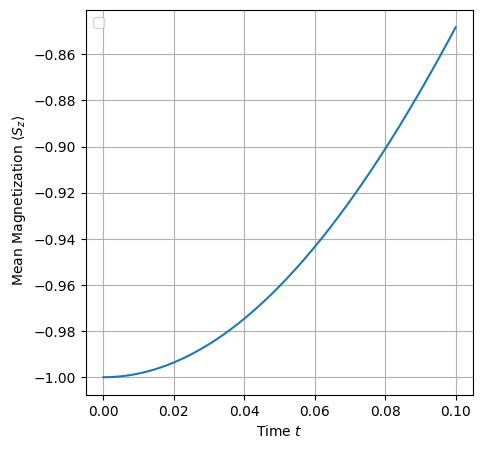

In [45]:
import matplotlib.pyplot as plt

fig1, axs1 = plt.subplots(1, 1, sharex=True, figsize=(5, 5))



# Plot imaginary parts
axs1.plot(times ,tdvp_Lindblad.operator_results()[0])




# axs1.plot(results_N_ttn, label="N_ttn")
# axs1.plot(results_N_t3n, label="N_t3n")

axs1.set_xlabel("Time $t$")
axs1.set_ylabel(" Mean Magnetization $\\langle S_z \\rangle$")
axs1.grid(True)
axs1.legend()